# Federated Learning Pipeline with Dataset Analysis
This notebook provides a comprehensive pipeline for analyzing air quality datasets and running federated learning simulations.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import yaml


## 1. Dataset Parsing Function

In [17]:
def parse_dataset_name(filename):
    parts = filename.split('_')
    interval = parts[2]
    year = parts[3]
    place = ' '.join(parts[7:-2])
    return {'interval': interval, 'year': year, 'place': place}

# Example usage
file_name = "Raw_data_15Min_2017_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv"
parsed_info = parse_dataset_name(file_name)
parsed_info

{'interval': '15Min', 'year': '2017', 'place': 'Bagh Delhi'}

## 2. Data Analysis Function

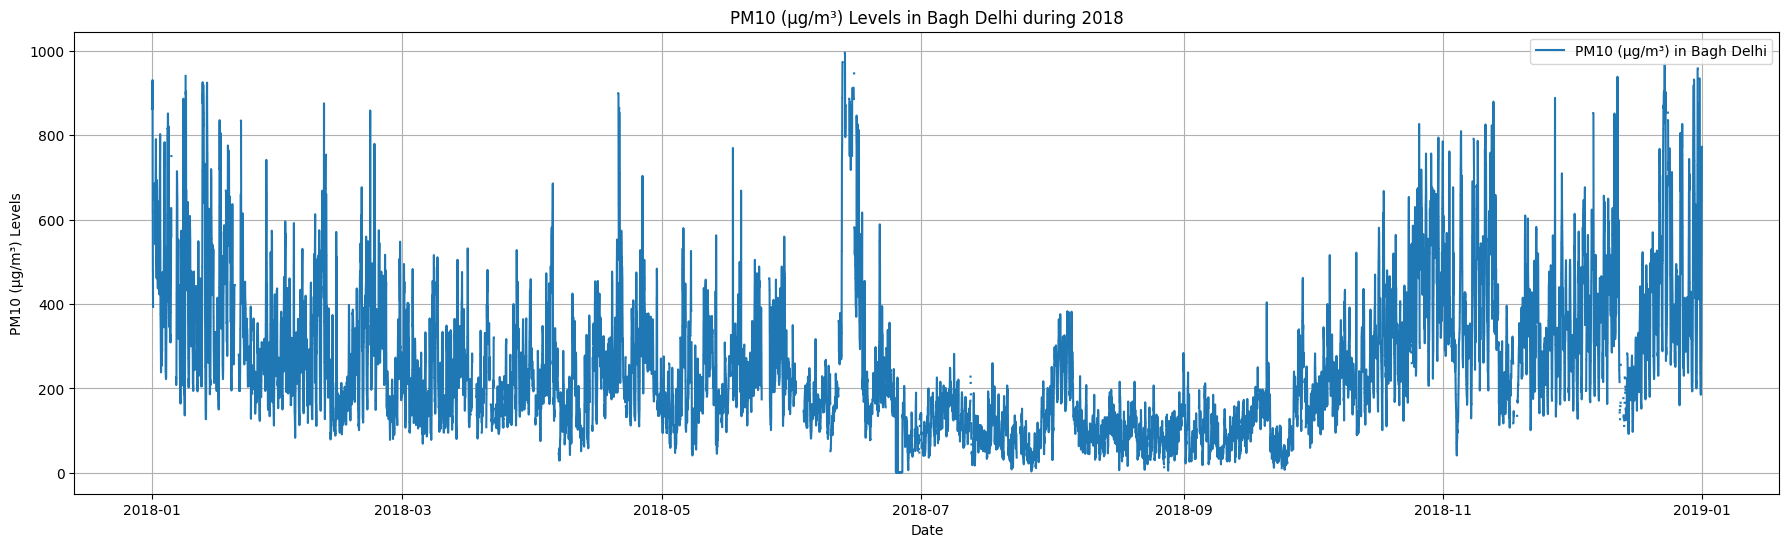

In [29]:
def analyze_pollutants(datasets, year, pollutant, place):
    combined_data = []
    for dataset in datasets:
        # print( dataset)
        info = parse_dataset_name(os.path.basename(dataset))
        # print(info)
        data = pd.read_csv(dataset)
        # print( data.columns)
        if info['year'] == str(year) and place.lower() in info['place'].lower():
            data = pd.read_csv(dataset)
            # print( data.columns)
            if pollutant in data.columns:
                data['datetime'] = pd.to_datetime(data['Timestamp'])
                combined_data.append(data[['datetime', pollutant]])
                

    if combined_data:
        combined_df = pd.concat(combined_data).sort_values('datetime')
        plt.figure(figsize=(22, 6))
        plt.plot(combined_df['datetime'], combined_df[pollutant], label=f'{pollutant} in {place}')
        plt.xlabel('Date')
        plt.ylabel(f'{pollutant} Levels')
        plt.title(f'{pollutant} Levels in {place} during {year}')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"No data found for {pollutant} in {place} during {year}.")

# Example usage
datasets = ["Dataset_Dehli/Raw_data_15Min_2018_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv"]
analyze_pollutants(datasets, 2018, 'PM10 (µg/m³)', 'Bagh Delhi')

## 3. Trend Analysis for Time-Series Suitability

In [37]:
def trend_analysis(data, pollutant):
    if pollutant in data.columns:
        data['datetime'] = pd.to_datetime(data['Timestamp'])
        data = data.sort_values('datetime')
        data = data.dropna(subset=[pollutant])  # Remove rows with NaN values in the pollutant column
        X = np.arange(len(data)).reshape(-1, 1)
        y = data[pollutant].values.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X, y)
        trend = model.coef_[0][0]
        print(f"Trend for {pollutant}: {trend}")
        return abs(trend) > 0.01  # Example threshold
    else:
        print(f"Pollutant {pollutant} not found in data.")
        return False

# Example usage
dataset = pd.read_csv("Dataset_Dehli/Raw_data_15Min_2017_site_125_Punjabi_Bagh_Delhi_DPCC_15Min.csv")
trend_analysis(dataset, 'PM10 (µg/m³)')

Trend for PM10 (µg/m³): 0.01020177978514372


np.True_